<a href="https://colab.research.google.com/github/marcorivera24/Data_Analytics_in_Network_Biology/blob/main/Advance_Coding_Project%20Network%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Task 1 – Constructing the biomedical knowledge graph:
Setup your Python environment and download the graph data from Github: https://github.com/hetio/hetionet/tree/master/hetnet/tsv Remember you have two files,

the node file (node.tsv) lists the unique ID, name and kind for all entities in the graph; and the edge file (edges.sif) lists all the connections between those entities.

Load the files and combine them to create your first graph structure. You can use any tools you prefer. Hint: You can save the graph, so you don’t need to re-build it all the times.

In [ ]:
import pandas as pd
import networkx as nx

nodes_df = pd.read_csv('nodes.tsv', sep='\t')
edges_df = pd.read_csv('edges.sif', sep='\t')


G = nx.DiGraph()


for idx, row in nodes_df.iterrows():
    G.add_node(row['id'], name=row['name'], kind=row['kind'])


for idx, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'], metaedge=row['metaedge'])


nx.write_graphml(G, "biomedical_graph.graphml")


G = nx.read_graphml("biomedical_graph.graphml")



####Task 2 – Analyzing the biomedical knowledge graph:
We now ask you to compute some metrics and analysis on the biomedical knowledge graph.
First of all:



###1) Compute and list the total number of entities for each unique kind.
  

Total number of entities for each unique kind:
                 Entity  Count
0                  Gene  20945
1    Biological Process  11381
2           Side Effect   5734
3    Molecular Function   2884
4               Pathway   1822
5              Compound   1552
6    Cellular Component   1391
7               Symptom    438
8               Anatomy    402
9   Pharmacologic Class    345
10              Disease    137


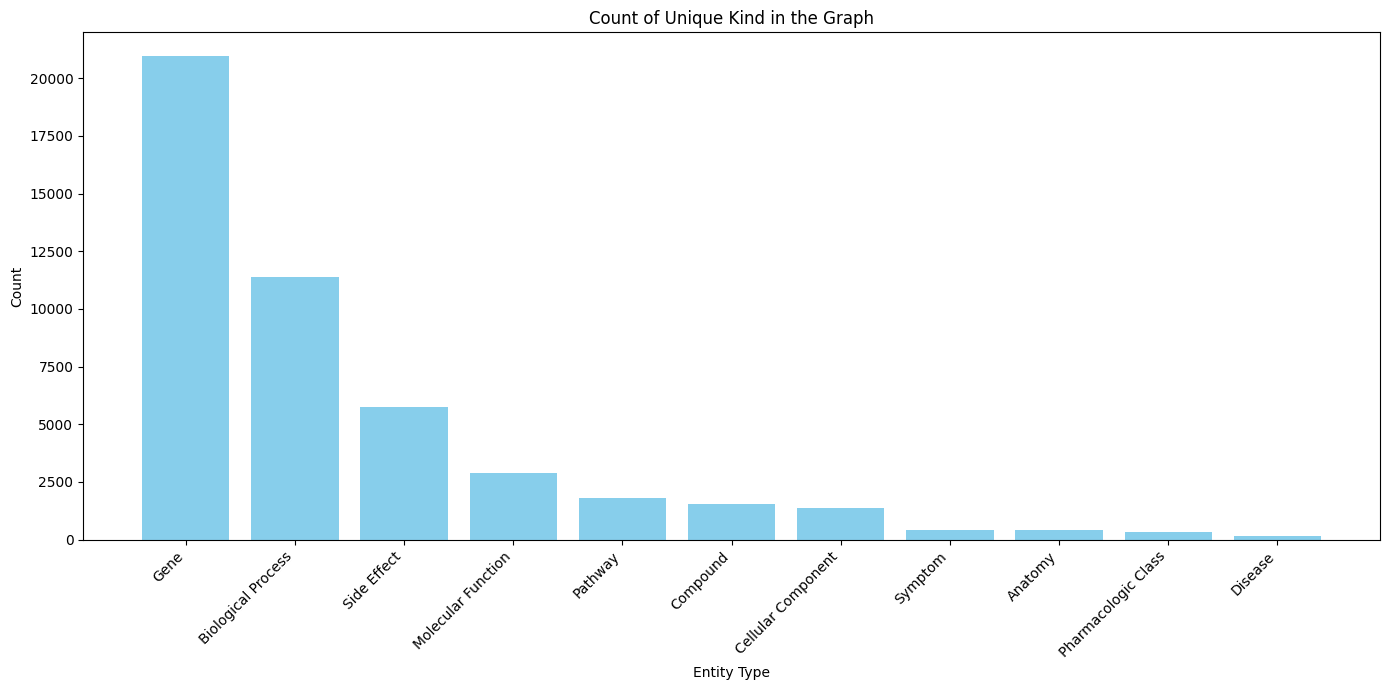

In [ ]:
# import networkx as nx
# import as pd
import matplotlib.pyplot as plt


Biograph = nx.read_graphml("biomedical_graph.graphml")


nodes_data = []
for node_id, node_data in Biograph.nodes(data=True):
    nodes_data.append(node_data)


nodes_df = pd.DataFrame(nodes_data)

# Compute the total number of entities for each unique kind
unique_kinds_counts = nodes_df['kind'].value_counts().reset_index()
unique_kinds_counts.columns = ['Entity', 'Count']

print("Total number of entities for each unique kind:")
print(unique_kinds_counts)


unique_kinds_counts.to_csv('unique_kinds_counts.csv', index=False)



plt.figure(figsize=(14, 7))
plt.bar(unique_kinds_counts['Entity'], unique_kinds_counts['Count'], color='skyblue')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.title('Count of Unique Kind in the Graph')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()


###2) Compute and list the total number of each unique edge type.

Total number of each unique edge type:
   Edge Type   Count
0       GpBP  559504
1        GiG  146926
2        AdG  102240
3        AuG   97848
4       GpMF   97222
5       GpCC   73566
6        GcG   61674
7       Gr>G   58993
8        CuG   18756
9        DaG   12623
10       CbG   11526
11       DdG    7508
12       CrC    6486
13       DlA    3602
14       DpS    3357
15      PCiC    1029
16       CtD     755
17       DrD     543
18       CpD     390
19         G       1


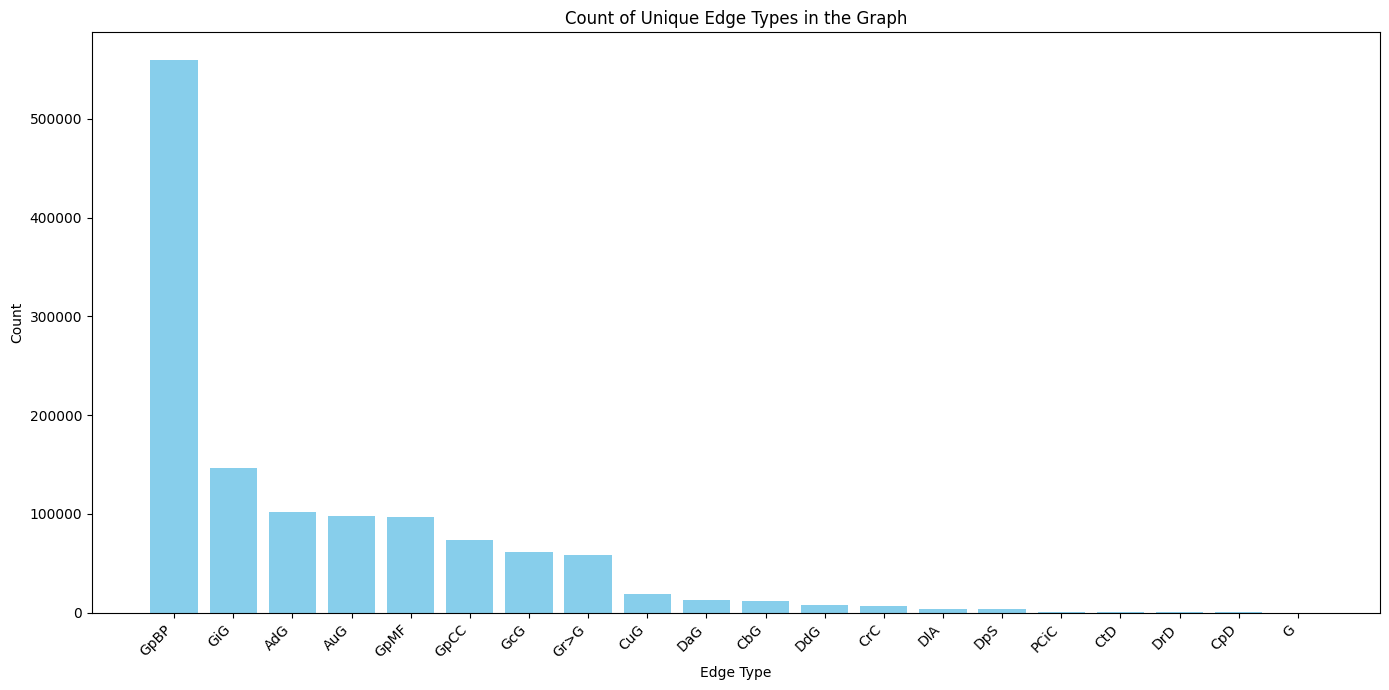

In [ ]:
#import networkx as nx
#import pandas as pd
import matplotlib.pyplot as plt


Biograph = nx.read_graphml("biomedical_graph.graphml")


edges_data = []
for source, target, edge_data in Biograph.edges(data=True):
    edge_data['source'] = source
    edge_data['target'] = target
    edges_data.append(edge_data)


edges_df = pd.DataFrame(edges_data)

# Compute and list the total number of each unique edge type
edge_type_counts = edges_df['metaedge'].value_counts().reset_index()
edge_type_counts.columns = ['Edge Type', 'Count']

print("Total number of each unique edge type:")
print(edge_type_counts)


edge_type_counts.to_csv('edge_type_counts.csv', index=False)


# Plotting
plt.figure(figsize=(14, 7))
plt.bar(edge_type_counts['Edge Type'], edge_type_counts['Count'], color='skyblue')
plt.xlabel('Edge Type')
plt.ylabel('Count')
plt.title('Count of Unique Edge Types in the Graph')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


###3) Compute the average in-degree and out-degree, for each type of node.

In [ ]:
import networkx as nx
import pandas as pd


Biograph = nx.read_graphml("biomedical_graph.graphml")

# Extract node
nodes_data = []
for node_id, node_data in Biograph.nodes(data=True):
    nodes_data.append({'id': node_id, **node_data})

nodes_df = pd.DataFrame(nodes_data)

# Compute in-degree and out-degree
in_degrees = dict(Biograph.in_degree())
out_degrees = dict(Biograph.out_degree())

nodes_df['in_degree'] = nodes_df['id'].map(in_degrees)
nodes_df['out_degree'] = nodes_df['id'].map(out_degrees)


average_degrees = nodes_df.groupby('kind').agg(
    avg_in_degree=pd.NamedAgg(column='in_degree', aggfunc='mean'),
    avg_out_degree=pd.NamedAgg(column='out_degree', aggfunc='mean')
).reset_index()


print(average_degrees)


output_filename = "average_in_out_degrees_nodes.csv"
average_degrees.to_csv(output_filename, index=False)



                   kind  avg_in_degree  avg_out_degree
0               Anatomy       8.960199      497.731343
1    Biological Process      49.161234        0.000000
2    Cellular Component      52.887132        0.000000
3              Compound       4.842139       24.428479
4               Disease      12.321168      201.700730
5                  Gene      24.735927       47.643161
6    Molecular Function      33.710818        0.000000
7               Pathway       0.000000        0.000000
8   Pharmacologic Class       0.000000        2.982609
9           Side Effect       0.000000        0.000000
10              Symptom       7.664384        0.000000


###TASK 2 Analysis
The graph is actually very huge! And you noticed it contains several heterogenous entities.
Let’s delve into it:
Analysis:

It’s important to understand how frequent and connected a disease is, and its symptom. Let’s
work on that:



Given what we learned, is now time for the final challenge:



###Task 2 Analysis    No. 1
1) For each “Disease” compute the number of connections (in-degree and out-degree) and show the most connected diseases

In [ ]:
import networkx as nx
import pandas as pd

# Load the graph from the GraphML file
Biograph = nx.read_graphml("biomedical_graph.graphml")


nodes_data = []
for node_id, node_data in Biograph.nodes(data=True):
    nodes_data.append({'id': node_id, **node_data})

nodes_df = pd.DataFrame(nodes_data)

# Filter out nodes that are of kind 'Disease'
disease_nodes = nodes_df[nodes_df['kind'] == 'Disease'].copy()


disease_nodes['in_degree'] = disease_nodes['id'].map(dict(Biograph.in_degree()))
disease_nodes['out_degree'] = disease_nodes['id'].map(dict(Biograph.out_degree()))


disease_nodes['total_connections'] = disease_nodes['in_degree'] + disease_nodes['out_degree']


disease_nodes_result = disease_nodes[['id', 'name', 'in_degree', 'out_degree', 'total_connections']]
disease_nodes_result.to_csv('diseases_connections.csv', index=False)

most_connected_diseases = disease_nodes.sort_values(by='total_connections', ascending=False).head(10)
most_connected_diseases_result = most_connected_diseases[['id', 'name', 'in_degree', 'out_degree', 'total_connections']]
most_connected_diseases_result.to_csv('most_connected_diseases.csv', index=False)

from IPython.display import display
display(disease_nodes_result)
display(most_connected_diseases_result)



,id,name,in_degree,out_degree,total_connections
14726,Disease::DOID:0050156,idiopathic pulmonary fibrosis,2,281,283
14727,Disease::DOID:0050425,restless legs syndrome,16,49,65
14728,Disease::DOID:0050741,alcohol dependence,6,274,280
14729,Disease::DOID:0050742,nicotine dependence,5,285,290
14730,Disease::DOID:0060073,lymphatic system cancer,9,9,18
...,...,...,...,...,...
14858,Disease::DOID:9744,type 1 diabetes mellitus,5,200,205
14859,Disease::DOID:9835,refractive error,3,153,156
14860,Disease::DOID:986,alopecia areata,1,280,281
14861,Disease::DOID:9917,pleural cancer,0,0,0


,id,name,in_degree,out_degree,total_connections
14784,Disease::DOID:1612,breast cancer,44,845,889
14804,Disease::DOID:2531,hematologic cancer,53,800,853
14739,Disease::DOID:10763,hypertension,73,648,721
14808,Disease::DOID:2986,IgA glomerulonephritis,0,708,708
14793,Disease::DOID:1909,melanoma,13,675,688
14842,Disease::DOID:7148,rheumatoid arthritis,38,615,653
14735,Disease::DOID:10283,prostate cancer,32,616,648
14818,Disease::DOID:3393,coronary artery disease,40,568,608
14833,Disease::DOID:5419,schizophrenia,34,557,591
14806,Disease::DOID:263,kidney cancer,21,521,542


###Task 2 Analysis No.2
2) Compute the sub-graph of “Disease” and “Symptom”. And compute the average number of connections between a disease and a symptom.

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations

# Load the full biomedical graph
Biograph = nx.read_graphml("biomedical_graph.graphml")

# Step 1: Filter for Disease and Symptom nodes, safely handling nodes without the 'kind' attribute
disease_symptom_nodes = [n for n, d in Biograph.nodes(data=True) if d.get('kind') in ['Disease', 'Symptom']]

# Step 2: Create a subgraph for Disease and Symptom nodes
subgraph = Biograph.subgraph(disease_symptom_nodes).copy()

# Step 3: Save the subgraph to a GraphML file
subgraph_filename = "disease_symptom_subgraph.graphml"
nx.write_graphml(subgraph, subgraph_filename)

# Output information about the subgraph
print(f"Sub-graph contains {subgraph.number_of_nodes()} nodes and {subgraph.number_of_edges()} edges.")


Sub-graph contains 575 nodes and 3900 edges.


In [ ]:



loaded_subgraph = nx.read_graphml(subgraph_filename)

# Find all disease-symptom edges
disease_symptom_edges = [(u, v) for u, v in loaded_subgraph.edges()
                         if (loaded_subgraph.nodes[u]['kind'] == 'Disease' and loaded_subgraph.nodes[v]['kind'] == 'Symptom') or
                            (loaded_subgraph.nodes[u]['kind'] == 'Symptom' and loaded_subgraph.nodes[v]['kind'] == 'Disease')]

# Calculate the average number of connections per disease
total_connections = len(disease_symptom_edges)
average_connections = total_connections / len([n for n in loaded_subgraph.nodes if loaded_subgraph.nodes[n]['kind'] == 'Disease'])

print(f"Total number of disease-symptom connections: {total_connections}")
print(f"Average number of connections per disease: {average_connections:.2f}")


Total number of disease-symptom connections: 3357
Average number of connections per disease: 24.50


###Task 2 Analysis No.3    
Now you may notice some symptoms can be associated with different diseases!! Also, some
diseases are very similar, let’s compute the similarity of them:


3) Compute the similarity between “type 1 diabetes mellitus” and “type 2 diabetes mellitus”

In [ ]:
import networkx as nx
import numpy as np
from sklearn.metrics import jaccard_score

subgraph = nx.read_graphml("disease_symptom_subgraph.graphml")


def find_disease_node(subgraph, disease_name):
    for node, data in subgraph.nodes(data=True):
        if data['name'].lower() == disease_name.lower():
            return node
    return None

disease_1_node = find_disease_node(subgraph, "Type 1 diabetes mellitus")
disease_2_node = find_disease_node(subgraph, "Type 2 diabetes mellitus")

# Check if both diseases were found
if disease_1_node is None or disease_2_node is None:
    raise ValueError("One or both diseases not found in the graph.")

def get_symptoms(subgraph, disease_node):
    return {neighbor for neighbor in subgraph.neighbors(disease_node) if subgraph.nodes[neighbor]['kind'] == 'Symptom'}

disease_1_symptoms = get_symptoms(subgraph, disease_1_node)
disease_2_symptoms = get_symptoms(subgraph, disease_2_node)


shared_symptoms = disease_1_symptoms.intersection(disease_2_symptoms)
shared_symptom_names = [subgraph.nodes[symptom]['name'] for symptom in shared_symptoms]


print("Shared symptoms between 'Type 1 diabetes mellitus' and 'Type 2 diabetes mellitus':")
print(shared_symptom_names)


all_symptoms = list(disease_1_symptoms.union(disease_2_symptoms))
disease_1_vector = np.array([1 if symptom in disease_1_symptoms else 0 for symptom in all_symptoms])
disease_2_vector = np.array([1 if symptom in disease_2_symptoms else 0 for symptom in all_symptoms])

# 1. Jaccard Similarity
jaccard_similarity = jaccard_score(disease_1_vector, disease_2_vector)
print(f"Jaccard Similarity: {jaccard_similarity:.4f}")

# 2. Dice Similarity (Sorensen-Dice Coefficient)
dice_similarity = 2 * np.sum(disease_1_vector & disease_2_vector) / (np.sum(disease_1_vector) + np.sum(disease_2_vector))
print(f"Dice Similarity: {dice_similarity:.4f}")

# 3. Cosine Similarity
cosine_similarity = np.dot(disease_1_vector, disease_2_vector) / (np.linalg.norm(disease_1_vector) * np.linalg.norm(disease_2_vector))
print(f"Cosine Similarity: {cosine_similarity:.4f}")

# 4. Overlap Coefficient
overlap_coefficient = np.sum(disease_1_vector & disease_2_vector) / min(np.sum(disease_1_vector), np.sum(disease_2_vector))
print(f"Overlap Coefficient: {overlap_coefficient:.4f}")


Shared symptoms between 'Type 1 diabetes mellitus' and 'Type 2 diabetes mellitus':
['Albuminuria', 'Body Weight', 'Gastroparesis', 'Birth Weight', 'Proteinuria', 'Weight Gain']
Jaccard Similarity: 0.1765
Dice Similarity: 0.3000
Cosine Similarity: 0.3145
Overlap Coefficient: 0.4286


###Task 2 Analysis No.4
Define and compute also the similarity between two symptoms like “Eye Pain” and
”Blindness”

What “similar” means? Two diseases could be similar if they share part of their neighbours,
or maybe you can do something more sophisticated :)

In [ ]:
#Visual Presenation of Disease-Symptom Subgraph

import random
import networkx as nx
import pandas as pd
import plotly.graph_objs as go
from plotly.offline import iplot




nodes_list = list(subgraph.nodes())
num_nodes = len(nodes_list)
sampled_nodes = random.sample(nodes_list, int(0.1 * num_nodes))


sampled_subgraph = subgraph.subgraph(sampled_nodes).copy()


labels = {node: data['name'] for node, data in sampled_subgraph.nodes(data=True)}


node_colors = ['red' if sampled_subgraph.nodes[node]['kind'] == 'Disease' else 'blue' for node in sampled_subgraph.nodes()]


pos = nx.spring_layout(sampled_subgraph, dim=3)

pos_df = pd.DataFrame(pos).T
pos_df.columns = ['x', 'y', 'z']


edge_trace = []
for edge in sampled_subgraph.edges():
    x0, y0, z0 = pos[edge[0]]
    x1, y1, z1 = pos[edge[1]]
    edge_trace.append(go.Scatter3d(
        x=[x0, x1, None],
        y=[y0, y1, None],
        z=[z0, z1, None],
        mode='lines',
        line=dict(color='gray', width=2),
        hoverinfo='none'
    ))


node_trace = go.Scatter3d(
    x=pos_df['x'],
    y=pos_df['y'],
    z=pos_df['z'],
    mode='markers+text',
    text=[labels[node] for node in sampled_subgraph.nodes()],
    textposition="top center",
    hoverinfo='text',
    marker=dict(
        color=node_colors,
        size=10,
        line=dict(width=2)
    )
)

# Combine the traces
fig = go.Figure(data=edge_trace + [node_trace],
                layout=go.Layout(
                    title="Disease-Symptom Subgraph",
                    showlegend=False,
                    scene=dict(
                        xaxis=dict(showbackground=False),
                        yaxis=dict(showbackground=False),
                        zaxis=dict(showbackground=False)
                    ),
                    margin=dict(l=0, r=0, b=0, t=50),
                ))


iplot(fig)


In [ ]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


graph_path = "biomedical_graph.graphml"
Biograph = nx.read_graphml(graph_path)

disease_symptoms = {}

for node, data in Biograph.nodes(data=True):
    if data.get('kind') == 'Disease':
        # Find all symptom neighbors
        symptoms = [neighbor for neighbor in Biograph.neighbors(node) if Biograph.nodes[neighbor].get('kind') == 'Symptom']
        disease_symptoms[data['name']] = [Biograph.nodes[symptom]['name'] for symptom in symptoms]


diseases_with_eye_pain = []
diseases_with_blindness = []

for disease, symptoms in disease_symptoms.items():
    if "Eye Pain" in symptoms:
        diseases_with_eye_pain.append(disease)
    if "Blindness" in symptoms:
        diseases_with_blindness.append(disease)



# 1. Jaccard Similarity
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

# 2. Cosine Similarity (treating as binary vectors)
def cosine_sim(set1, set2, universe):
    vector1 = np.array([1 if disease in set1 else 0 for disease in universe])
    vector2 = np.array([1 if disease in set2 else 0 for disease in universe])
    # Calculate cosine similarity
    return cosine_similarity([vector1], [vector2])[0][0]

# 3. Dice Similarity
def dice_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    return 2 * intersection / (len(set1) + len(set2)) if (len(set1) + len(set2)) != 0 else 0


set_eye_pain = set(diseases_with_eye_pain)
set_blindness = set(diseases_with_blindness)


all_diseases = set(disease_symptoms.keys())


jaccard = jaccard_similarity(set_eye_pain, set_blindness)
cosine = cosine_sim(set_eye_pain, set_blindness, all_diseases)
dice = dice_similarity(set_eye_pain, set_blindness)


print(f"Shared diseases between 'Eye Pain' and 'Blindness': {', '.join(set_eye_pain.intersection(set_blindness))}")

print(f"\nJaccard Similarity: {jaccard:.4f}")
print(f"Cosine Similarity: {cosine:.4f}")
print(f"Dice Similarity: {dice:.4f}")


Shared diseases between 'Eye Pain' and 'Blindness': age related macular degeneration, refractive error, bone cancer, glaucoma, germ cell cancer, ocular cancer, melanoma

Jaccard Similarity: 0.3500
Cosine Similarity: 0.5916
Dice Similarity: 0.5185


### Task 2 Analysis No.5

5) Suppose you have an imaginary patient with one symptom (of your choice). Try to help them with some data analysis (e.g., study the possible diseases, select the disease, the gene, the possible compounds, the side effects, try to mitigate side effects, and so on...)





### Run the code and type the Symptom

In [ ]:
import networkx as nx

# Load the graph from the provided file
graph_file_path = 'biomedical_graph.graphml'
Biograph = nx.read_graphml(graph_file_path)

def find_related_entities(symptom_name):
    diseases = set()
    genes = set()
    compounds = set()
    pharmacologic_classes = set()
    side_effects = {}


    symptom_name_lower = symptom_name.lower()

    # Find the node corresponding to the input symptom
    symptom_node = None
    for node, data in Biograph.nodes(data=True):
        if data.get('name', '').lower() == symptom_name_lower and data.get('kind') == 'Symptom':
            symptom_node = node
            break

    if not symptom_node:
        return f"Symptom '{symptom_name}' not found in the graph."

    # Find diseases associated with the symptom
    for u, v in Biograph.edges():
        if u == symptom_node and Biograph.nodes[v]['kind'] == 'Disease':
            diseases.add(v)
        elif v == symptom_node and Biograph.nodes[u]['kind'] == 'Disease':
            diseases.add(u)

    # Prepare the results
    results = []
    for disease in diseases:
        disease_name = Biograph.nodes[disease]['name']
        disease_info = {
            "Disease": disease_name,
            "Genes": [],
            "Compounds": [],
            "Pharmacologic Classes": [],
            "Side Effects": {}
        }

        # Find genes associated with the disease
        gene_count = 0
        for u, v in Biograph.edges():
            if u == disease and Biograph.nodes[v]['kind'] == 'Gene':
                disease_info["Genes"].append(Biograph.nodes[v]['name'])
                gene_count += 1
                if gene_count >= 10:
                    break
            elif v == disease and Biograph.nodes[u]['kind'] == 'Gene':
                disease_info["Genes"].append(Biograph.nodes[u]['name'])
                gene_count += 1
                if gene_count >= 10:
                    break

        # Find compounds and pharmacologic classes associated with the disease
        for u, v in Biograph.edges():
            if u == disease and Biograph.nodes[v]['kind'] == 'Compound':
                compound_name = Biograph.nodes[v]['name']
                disease_info["Compounds"].append(compound_name)
                disease_info["Side Effects"][compound_name] = []
                # Find side effects associated with the compound
                side_effect_count = 0
                for cu, cv in Biograph.edges(v):
                    if Biograph.nodes[cv]['kind'] == 'Side Effect':
                        disease_info["Side Effects"][compound_name].append(Biograph.nodes[cv]['name'])
                        side_effect_count += 1
                        if side_effect_count >= 5:
                            break
            elif v == disease and Biograph.nodes[u]['kind'] == 'Compound':
                compound_name = Biograph.nodes[u]['name']
                disease_info["Compounds"].append(compound_name)
                disease_info["Side Effects"][compound_name] = []
                # Find side effects associated with the compound
                side_effect_count = 0
                for cu, cv in Biograph.edges(u):
                    if Biograph.nodes[cv]['kind'] == 'Side Effect':
                        disease_info["Side Effects"][compound_name].append(Biograph.nodes[cv]['name'])
                        side_effect_count += 1
                        if side_effect_count >= 5:
                            break

            if u == disease and Biograph.nodes[v]['kind'] == 'Pharmacologic Class':
                pharm_class_name = Biograph.nodes[v]['name']
                disease_info["Pharmacologic Classes"].append(pharm_class_name)
                disease_info["Side Effects"][pharm_class_name] = []
                # Find side effects associated with the pharmacologic class
                side_effect_count = 0
                for cu, cv in Biograph.edges(v):
                    if Biograph.nodes[cv]['kind'] == 'Side Effect':
                        disease_info["Side Effects"][pharm_class_name].append(Biograph.nodes[cv]['name'])
                        side_effect_count += 1
                        if side_effect_count >= 5:
                            break
            elif v == disease and Biograph.nodes[u]['kind'] == 'Pharmacologic Class':
                pharm_class_name = Biograph.nodes[u]['name']
                disease_info["Pharmacologic Classes"].append(pharm_class_name)
                disease_info["Side Effects"][pharm_class_name] = []
                # Find side effects associated with the pharmacologic class
                side_effect_count = 0
                for cu, cv in Biograph.edges(u):
                    if Biograph.nodes[cv]['kind'] == 'Side Effect':
                        disease_info["Side Effects"][pharm_class_name].append(Biograph.nodes[cv]['name'])
                        side_effect_count += 1
                        if side_effect_count >= 5:
                            break

        results.append(disease_info)

    return results

# Example interaction with user input
symptom_input = input("Please type the symptom you have: ").strip()
result = find_related_entities(symptom_input)

if isinstance(result, str):
    print(result)
else:
    # Print the results
    print("\nThe possible diseases you have are:\n")
    for disease_info in result:
        print(f"Disease: {disease_info['Disease']}")
        print("   Some Genes associated with this disease are:")
        for gene in disease_info["Genes"]:
            print(f"        - {gene}")

        print("    Possible cure Compounds and Pharmacologic Classes:")
        for compound in disease_info["Compounds"]:
            print(f"        - Compound: {compound}")
            if disease_info["Side Effects"][compound]:
                print(f"          Some Side Effects associated are:")
                for side_effect in disease_info["Side Effects"][compound]:
                    print(f"                - {side_effect}")
            else:
                print("            No known side effects")

        for pharm_class in disease_info["Pharmacologic Classes"]:
            print(f"        - Pharmacologic Class: {pharm_class}")
            if disease_info["Side Effects"][pharm_class]:
                print(f"           Some Side Effects associated this are:")
                for side_effect in disease_info["Side Effects"][pharm_class]:
                    print(f"                - {side_effect}")
            else:
                print("            No known side effects")

        print("")  # Blank line between diseases


Please type the symptom you have: Hemoglobinuria

The possible diseases you have are:

Disease: malaria
   Some Genes associated with this disease are:
        - BIN1
        - DNPH1
        - THOC3
        - LRRN3
        - MEN1
        - LRRCC1
        - TCEB3CL
        - SNURF
        - VSX2
        - NVL
    Possible cure Compounds and Pharmacologic Classes:
        - Compound: Pyrimethamine
          Some Side Effects associated are:
                - Pulmonary eosinophilia
                - Anaemia megaloblastic
                - Thrombocytopenia
                - Toxic epidermal necrolysis
                - Decreased appetite
        - Compound: Dapsone
          Some Side Effects associated are:
                - Protein urine present
                - Hypoalbuminaemia
                - Tinnitus
                - Skin exfoliation
                - Anoxia
        - Compound: Doxycycline
            No known side effects
        - Compound: Sulfadiazine
          Some Side Effect

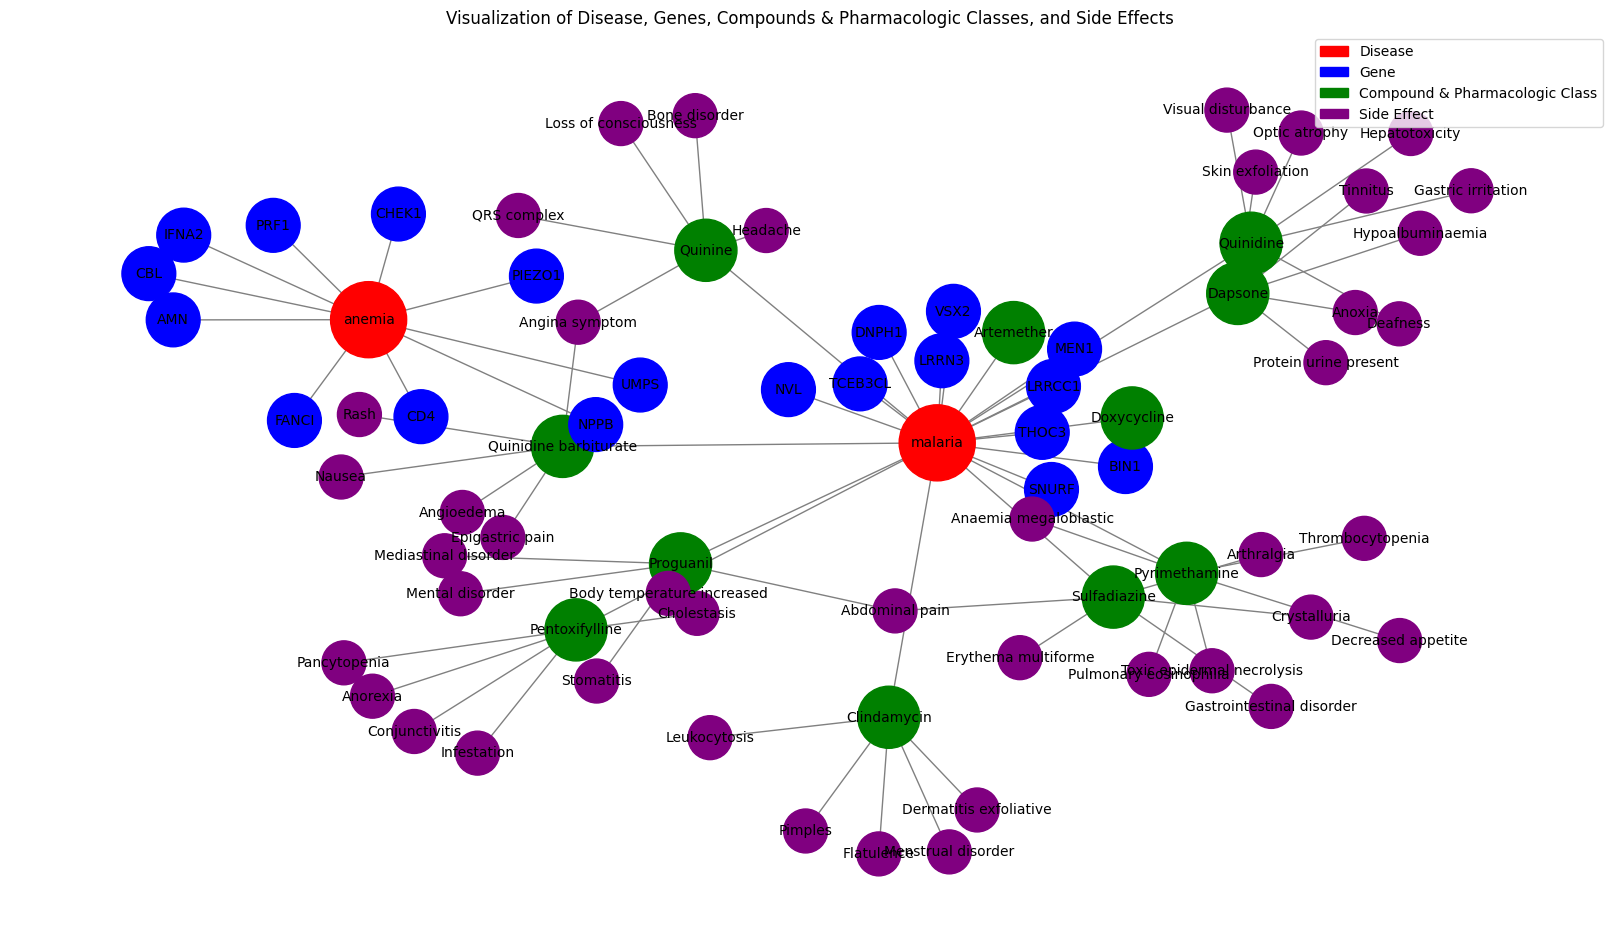

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_results(result):
    G = nx.Graph()

    for disease_info in result:
        disease_node = disease_info['Disease']
        G.add_node(disease_node, label='Disease', color='red', size=3000)

        # Add genes associated with the disease
        for gene in disease_info['Genes']:
            G.add_node(gene, label='Gene', color='blue', size=1500)
            G.add_edge(disease_node, gene)

        # Add compounds and pharmacologic classes associated with the disease
        for compound in disease_info['Compounds']:
            G.add_node(compound, label='Compound', color='green', size=2000)
            G.add_edge(disease_node, compound)
            # Add side effects associated with the compound
            for side_effect in disease_info['Side Effects'][compound]:
                G.add_node(side_effect, label='Side Effect', color='purple', size=1000)
                G.add_edge(compound, side_effect)

        for pharm_class in disease_info['Pharmacologic Classes']:
            G.add_node(pharm_class, label='Pharmacologic Class', color='orange', size=2000)
            G.add_edge(disease_node, pharm_class)
            # Add side effects associated with the pharmacologic class
            for side_effect in disease_info['Side Effects'][pharm_class]:
                G.add_node(side_effect, label='Side Effect', color='purple', size=1000)
                G.add_edge(pharm_class, side_effect)

    # Set colors and sizes based on node attributes
    colors = [G.nodes[node]['color'] for node in G.nodes]
    sizes = [G.nodes[node]['size'] for node in G.nodes]

    # Set figure size to be wider than taller (landscape)
    plt.figure(figsize=(16, 9))  # 16:9 aspect ratio for landscape orientation

    # Positioning nodes for a landscape orientation
    pos = nx.spring_layout(G, k=0.3, scale=2, center=(0, 0), dim=2)
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=sizes, font_size=10, font_color='black', edge_color='gray')

    # Add legends
    red_patch = mpatches.Patch(color='red', label='Disease')
    blue_patch = mpatches.Patch(color='blue', label='Gene')
    green_patch = mpatches.Patch(color='green', label='Compound & Pharmacologic Class')
    purple_patch = mpatches.Patch(color='purple', label='Side Effect')
    plt.legend(handles=[red_patch, blue_patch, green_patch, purple_patch], loc='upper right')

    plt.title("Visualization of Disease, Genes, Compounds & Pharmacologic Classes, and Side Effects")
    plt.show()

visualize_results(result)
